## Imports

In [1]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline

from dm_control.mujoco.wrapper.core import MjvOption

from flybody.fly_envs import (
    flight_imitation,
    vision_guided_flight,
)
from flybody.tasks.task_utils import (
    get_random_policy,
    real2canonical,
)
from flybody.tasks.constants import _FLY_PHYSICS_TIMESTEP, _FLY_CONTROL_TIMESTEP
from flybody.tasks.synthetic_trajectories import constant_speed_trajectory
from flybody.agents.utils_tf import TestPolicyWrapper
from flybody.utils import (
    display_video,
    rollout_and_render,
    rollout_ablate_render,
)

import tensorflow as tf
import tensorflow_probability as tfp
from acme import wrappers

# Prevent tensorflow from stealing all gpu memory.
physical_devices = tf.config.list_physical_devices('GPU')
print("physical devices:",physical_devices)
for device in physical_devices:
    tf.config.experimental.set_memory_growth(device, True)

/home/exj5139/miniconda3/envs/flybody/lib/python3.10/site-packages/tensorflow/python/framework/dtypes.py:205: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  np.bool8: (False, True),
/home/exj5139/miniconda3/envs/flybody/lib/python3.10/site-packages/tensorboard/compat/tensorflow_stub/dtypes.py:326: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  np.bool8: (False, True),
/home/exj5139/miniconda3/envs/flybody/lib/python3.10/site-packages/reverb/platform/default/ensure_tf_install.py:53: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if (distutils.version.LooseVersion(version) <
/home/exj5139/miniconda3/envs/flybody/lib/python3.10/site-packages/reverb/platform/default/ensure_tf_install.py:54: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  distutils.version.LooseVersion(required_tensorflow_version)):
/

physical devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


### Initialization

In [ ]:
# follow this chart for editing fruitfly.xml
#war,l1,y,mass
#0.5,0.057,0.091,4e-06
#0.6,0.0684,0.1024,4.8e-06
#0.7,0.0798,0.1138,5.6e-06
#0.8,0.0912,0.1252,6.4e-06
#0.9,0.1026,0.1366,7.2e-06
#1.0,0.1140,0.1480,8e-06

flight_imitation_path = '/home/exj5139/Downloads/datasets_flight-imitation/'
wpg_pattern_path = flight_imitation_path+'wing_pattern_fmech.npy'
ref_flight_path = flight_imitation_path+'flight-dataset_saccade-evasion_augmented.hdf5'

policy_path = '/home/exj5139/Downloads/trained-fly-policies/'
flight_policy_path = policy_path+'flight'
vision_bumps_path = policy_path+'vision-bumps'
vision_trench_path = policy_path+'vision-trench'

save_directory = '/home/exj5139/Downloads/initialized_damage_experiments/base_policy/100_wing_area_ratio/'

# User define here
t_total     = 0.08 # total simulation time, s: this is a rough approximation of the maximum time it would take for a fly to free-fall past the trajectory error limit
fly_speed   = 20. # cm/s
framerate   = 60  # video framerate, fps
t_video     = 10. # length of video, s NOTE: if t_total is low enough and/or framerate is high enough, this value will be ignored and no frames will be skipped
camera_ids = [1, -1] # Flybody cameras

### Definitions

In [3]:
# Rendering options
scene_opt = MjvOption()
scene_opt.geomgroup = [1,0,0,1,1,0]
render_kwargs = {'width': 640, 'height': 480, 'scene_option': scene_opt}

# Allocate.
n_steps = int(t_total /_FLY_PHYSICS_TIMESTEP) # frames
frames_between_render = max(1, int(t_total / (_FLY_PHYSICS_TIMESTEP * t_video * framerate))) # number of frames to wait before rendering next frame, based on the input parameters
frames_0 = []
frames_1 = []
joints_pos  = np.nan * np.zeros((n_steps, 25))  # Proprioception: observable joint angles.
vel         = np.nan * np.zeros((n_steps, 3))  # Velocimeter.
zaxis       = np.nan * np.zeros((n_steps, 3))  # Gravity direction.
root_qpos   = np.nan * np.zeros((n_steps, 7))  # Fly's position and orientation.
actions     = np.nan * np.zeros((n_steps, 6))  # Wing action commands.

print(
    "total steps:",n_steps, 
    "\nframes between render:", frames_between_render
)

def blow(x, repeats=2):
    """Repeat columns and rows requested number of times."""
    return np.repeat(np.repeat(x, repeats, axis=0), repeats, axis=1)


def vision_rollout_and_render(env, policy, camera_id=1,
                              eye_blow_factor=5, **render_kwargs):
    """Run vision-guided flight episode and render frames, including eyes."""
    frames = []
    timestep = env.reset()
    # Run full episode until it ends.
    while timestep.step_type != 2:
        # Render eyes and scene.
        pixels = env.physics.render(camera_id=camera_id, **render_kwargs)
        eyes = eye_pixels_from_observation(
            timestep, blow_factor=eye_blow_factor)
        # Add eye pixels to scene.
        pixels[0:eyes.shape[0], 0:eyes.shape[1], :] = eyes
        frames.append(pixels)
        # Step environment.
        action = policy(timestep.observation)
        timestep = env.step(action)
    return frames


def eye_pixels_from_observation(timestep, blow_factor=4):
    """Get current eye view from timestep.observation."""
    # In the actual task, the averaging over axis=-1 is done by the visual
    # network as a pre-processing step, so effectively the visual observations
    # are gray-scale.
    left_eye = timestep.observation['walker/left_eye'].mean(axis=-1)
    right_eye = timestep.observation['walker/right_eye'].mean(axis=-1)
    pixels = np.concatenate((left_eye, right_eye), axis=1)
    pixels = np.tile(pixels[:, :, None], reps=(1, 1, 3))
    pixels = blow(pixels, blow_factor)
    half_size = pixels.shape[1] // 2
    # Add white line to separate eyes.
    pixels = np.concatenate((pixels[:, :half_size, :], 
                            255*np.ones((blow_factor*32, 2, 3)),
                            pixels[:, half_size:, :]), axis=1)
    pixels = pixels.astype('uint8')
    return pixels


def eye_pixels_from_cameras(physics, **render_kwargs):
    """Render two-eye view, assuming eye cameras have particular names."""
    for i in range(physics.model.ncam):
        name = physics.model.id2name(i, 'camera')
        if 'eye_left' in name:
            left_eye = physics.render(camera_id=i, **render_kwargs)
        if 'eye_right' in name:
            right_eye = physics.render(camera_id=i, **render_kwargs)
    pixels = np.hstack((left_eye, right_eye))
    return pixels

def plot(save_dir,ctrl_ts, joints_pos, actions, root_qpos):
    time_axis = np.arange(n_steps) * ctrl_ts * 1000  # ms
    joint_labels = []
    for i in range(7):
        joint_labels.append(f"abduct{i}")
        joint_labels.append(f"extend{i}")
    
    # Proprioception plot
    plt.figure(figsize=(6, 10))
    plt.suptitle('Proprioception sensory inputs: head, abdomen, wing joint angles')
    plt.subplot(4, 1, 1)  # Head joints.
    plt.plot(time_axis, joints_pos[:, :3], label=['head_abduct', 'head_twist', 'head'])
    plt.ylabel('Head joint angles (rad)')
    plt.legend()
    plt.subplot(4, 1, 2)  # Abdomen joints.
    plt.plot(time_axis, joints_pos[:, 9:23], label=joint_labels)
    plt.ylabel('Abdomen joint angles (rad)')
    plt.subplot(4, 1, 3)  # Left wing.
    plt.plot(time_axis, joints_pos[:, 3:6], label=['yaw', 'roll', 'pitch'])
    plt.ylabel('Left wing angles (rad)')
    plt.legend()
    plt.subplot(4, 1, 4)  # Right wing.
    plt.plot(time_axis, joints_pos[:, 6:9])
    plt.xlabel('Time (ms)')
    plt.ylabel('Right wing angles (rad)')
    plt.tight_layout()
    plt.savefig(save_dir+r"proprioception.svg")

    # Dimensionless action specs
    plt.figure(figsize=(6,10))
    plt.subplot(2, 1, 1)
    plt.plot(time_axis, actions[:, :3], label=['yaw', 'roll', 'pitch'])
    plt.ylabel('Left wing control\n(unitless)')
    plt.legend()
    plt.subplot(2, 1, 2)
    plt.plot(time_axis, actions[:, 3:])
    plt.xlabel('Time (ms)')
    plt.ylabel('Right wing control')
    plt.tight_layout()
    plt.savefig(save_dir+r"wing_actions.svg")

    # Position
    plt.figure(figsize=(6,10))
    plt.subplot(2, 1, 1)
    plt.plot(time_axis, root_qpos[:, :3], label=['x', 'y', 'z'])
    plt.ylabel('Global Position (cm)')
    plt.legend()
    plt.subplot(2, 1, 2)
    plt.plot(time_axis, root_qpos[:, 3:], label=['w', 'x', 'y', 'z'])
    plt.xlabel('Time (ms)')
    plt.ylabel('Global Quaternion')
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_dir+r"pose.svg")

total steps: 1600 
frames between render: 2


### Simulation

In [4]:
# Construct environment and modify trajectory
env = flight_imitation(None,
                       wpg_pattern_path,
                       terminal_com_dist=float('inf'))
qpos, qvel = constant_speed_trajectory(
            n_steps=n_steps, speed=fly_speed, init_pos=(0, 0, 1),
            body_rot_angle_y=-47.5, control_timestep=_FLY_CONTROL_TIMESTEP)
env.task._traj_generator.set_next_trajectory(qpos, qvel)


# Wrap environment and policy
env = wrappers.SinglePrecisionWrapper(env)
env = wrappers.CanonicalSpecWrapper(env, clip=True)

flight_policy = tf.saved_model.load(flight_policy_path)
flight_policy = TestPolicyWrapper(flight_policy)

# Simulation looop, modified rollout_and_render
if isinstance(camera_ids, int):
    camera_ids = [camera_ids]
timestep = env.reset()
videos = []
i = 0
while(timestep.step_type != 2):
    # Record some of the sensory inputs.
    joints_pos[i] = timestep.observation['walker/joints_pos']
    vel[i] = timestep.observation['walker/velocimeter']
    zaxis[i] = timestep.observation['walker/world_zaxis']
    root_qpos[i] = env.physics.data.qpos[:7].copy()
    
    # Render
    frames_0.append(env.physics.render(camera_id=camera_ids[0], **render_kwargs))
    frames_1.append(env.physics.render(camera_id=camera_ids[1], **render_kwargs))

    # Advance simulation
    action = flight_policy(timestep.observation)
    timestep = env.step(action)

    # Record wing action commands.
    actions[i] = action[3:9]

    # Step index counter
    i += 1    

In [5]:
display_video(frames_0,framerate)

In [6]:
display_video(frames_1,framerate)

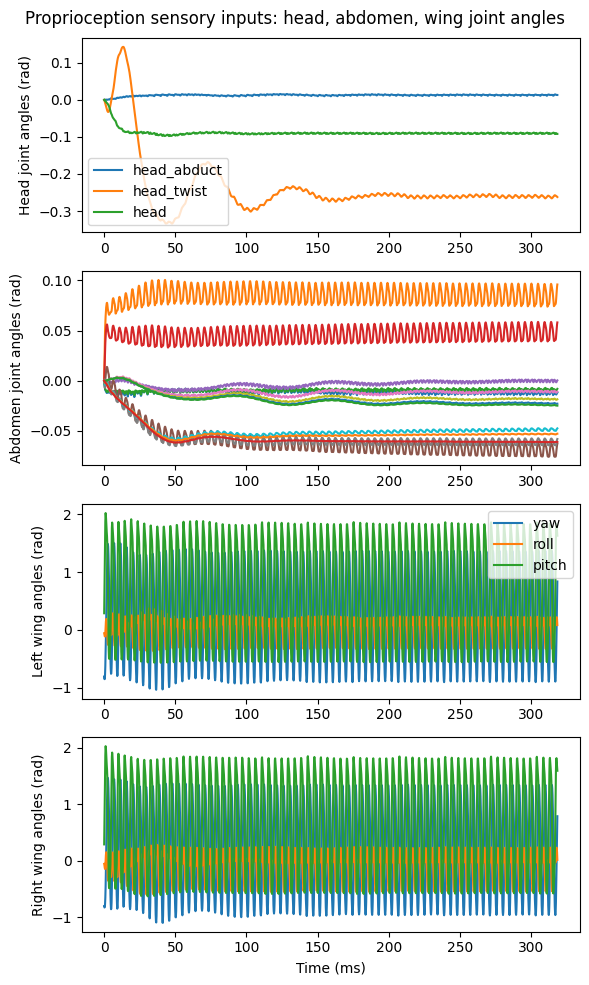

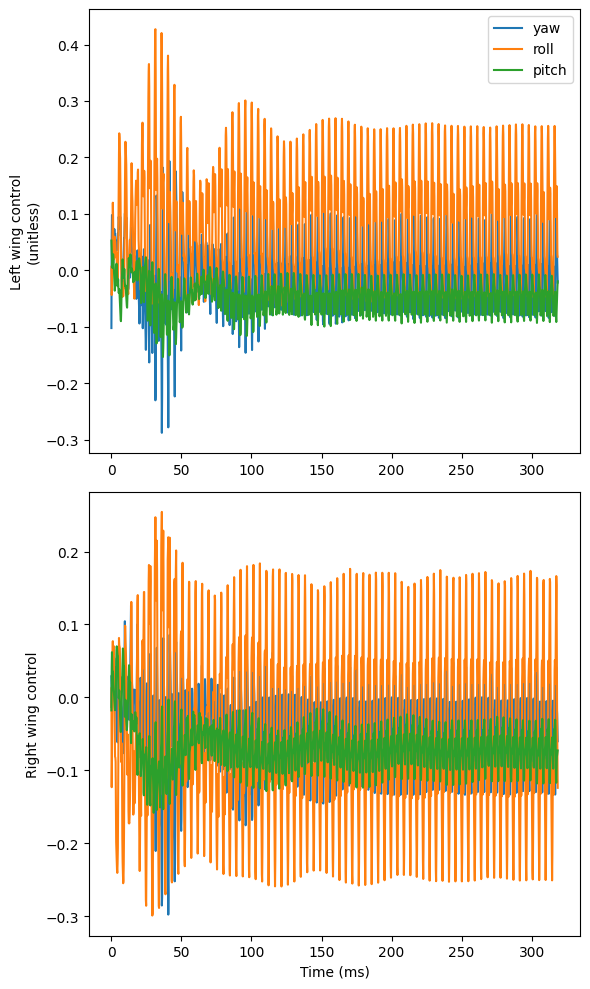

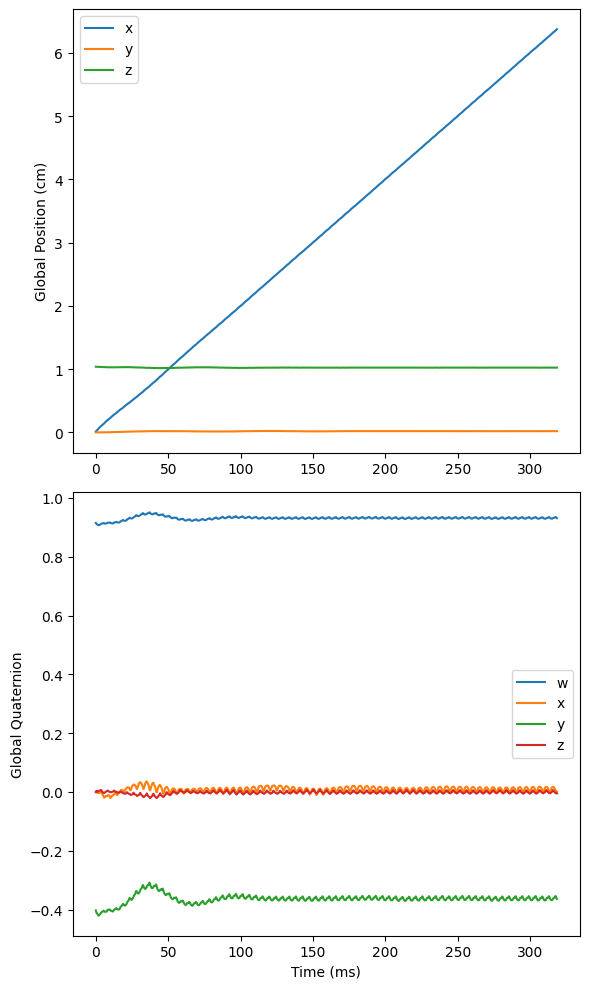

In [7]:
#plot and save
from scipy.io import savemat
plot(
    save_directory,
    env.control_timestep(),
    joints_pos,
    actions,
    root_qpos)

savemat(save_directory+'results.mat', {"joints_pos":joints_pos,"actions":actions,"root_qpos":root_qpos})